[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!



Available columns: ['title', 'pubDate', 'guid', 'link', 'description']
✅ Using text column: description
Total articles: 42115
Sample text:
 The Ukrainian president says the country will not forgive or forget those who murder its civilians.

Preprocessing texts...


100%|██████████| 42115/42115 [00:06<00:00, 6859.91it/s] 



🟦 LDA Topics:
Topic 0: bbc, election, look, world, general, news, across, year, first, northern, ireland, week
Topic 1: ukraine, russia, russian, bbc, war, say, life, ukrainian, show, video, year, force
Topic 2: england, world, final, cup, win, league, manchester, first, say, watch, woman, game
Topic 3: year, old, say, open, two, court, murder, man, johnson, british, police, award
Topic 4: say, people, day, new, help, year, find, going, past, seven, time, could
Topic 5: say, people, police, attack, israel, killed, died, two, home, gaza, year, found
Topic 6: say, former, leader, new, president, party, minister, star, first, trump, said, bbc
Topic 7: government, paper, price, plan, lead, bill, energy, king, pay, say, high, strike

🟩 NMF Topics:
Topic 0: say, police, family, official, could, want, man, expert, officer, would, england, report
Topic 1: world, cup, england, final, woman, win, watch, semi, first, one, beat, australia
Topic 2: day, seven, past, closely, going, attention, payi

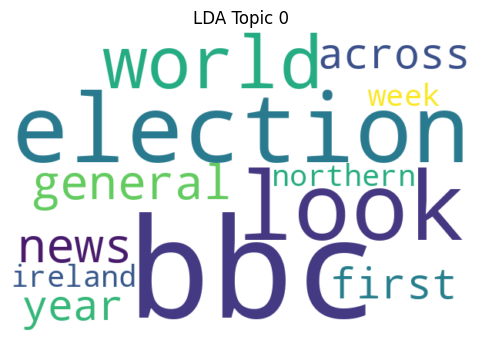

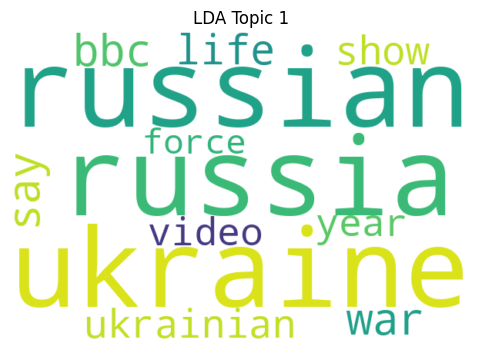

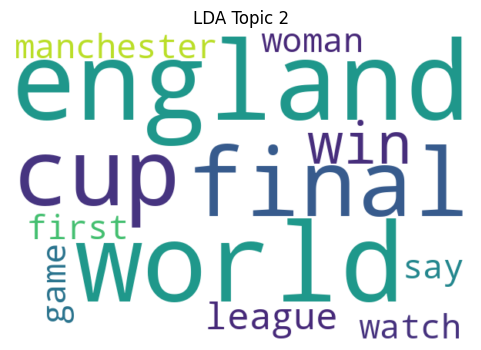

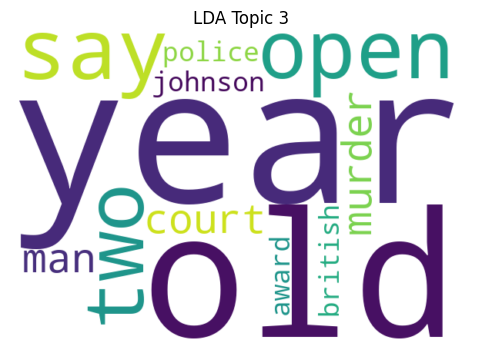

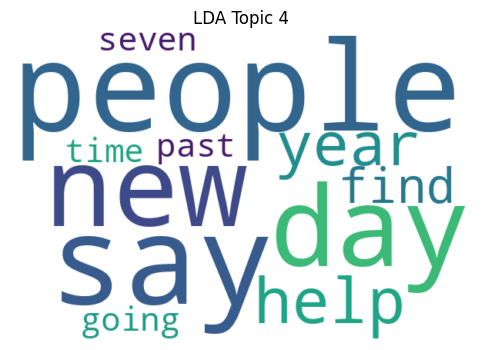

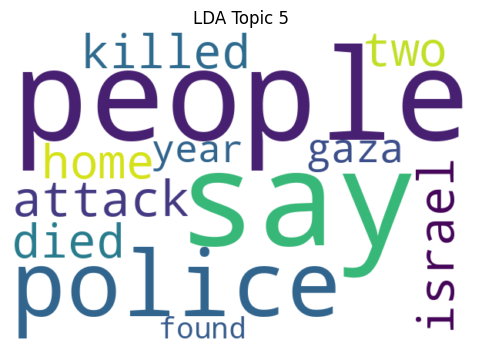

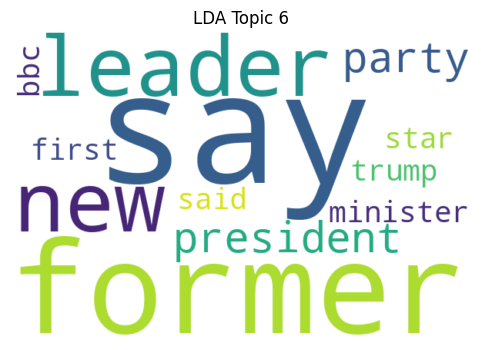

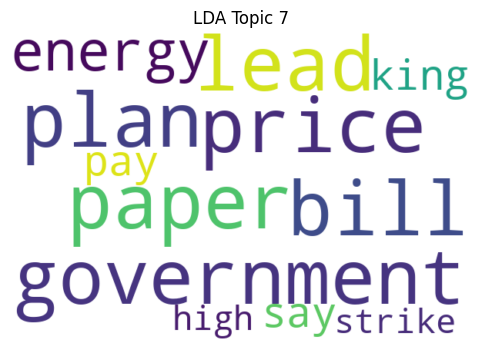

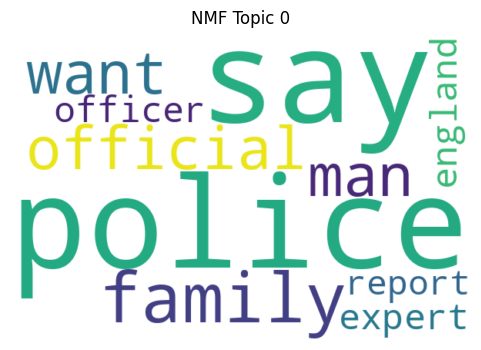

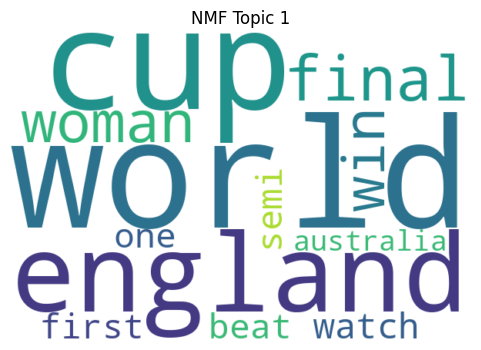

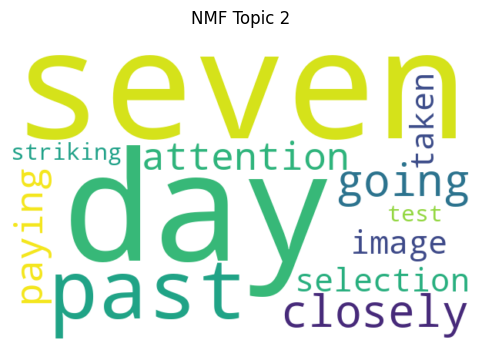

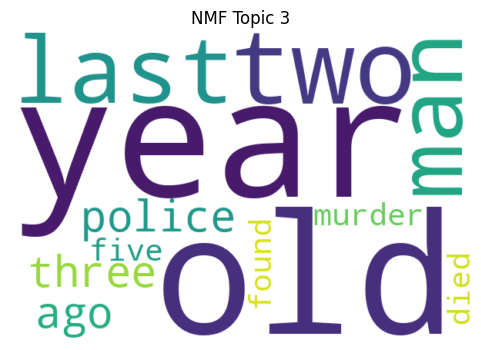

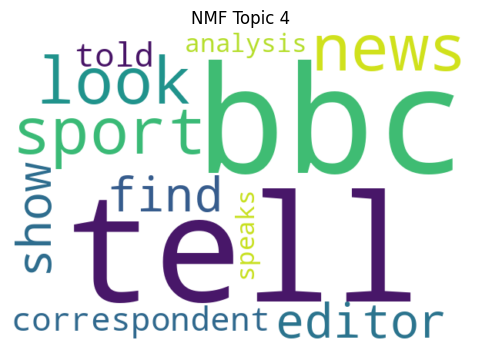

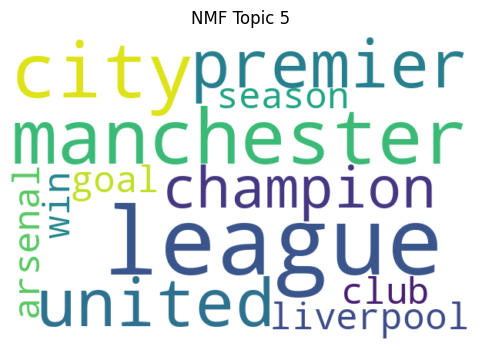

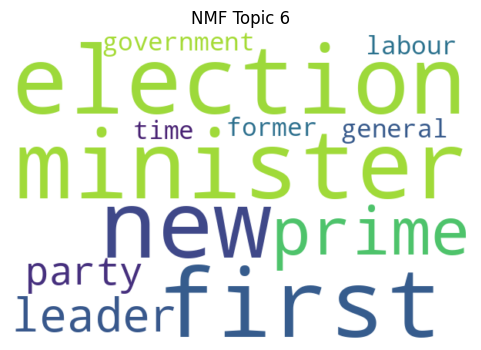

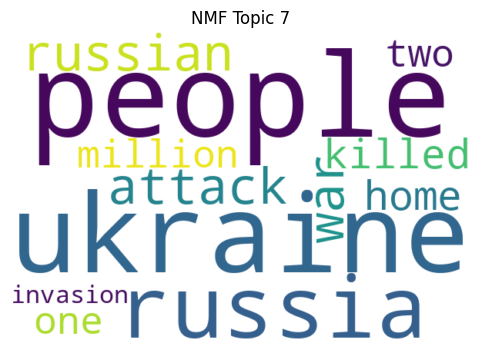


📊 Average LDA Coherence ≈ -3.5482
📊 Average NMF Coherence ≈ -3.0869

🧩 Example Article Topic Assignments:

Article #8978: pedestrian kyiv klitschko bridge narrow escape russian missile hit walkway...
 → LDA Topic: 1 | NMF Topic: 7

Article #41380: former arkansas governor new york real estate investor staunch supporter israel...
 → LDA Topic: 6 | NMF Topic: 6

Article #38662: day day guide happening watch paris paralympics...
 → LDA Topic: 2 | NMF Topic: 2

Article #39325: lando norris beat title rival max verstappen pole position dramatic qualifying session singapore gra...
 → LDA Topic: 1 | NMF Topic: 5

Article #323: bryn perry pembrokeshire recycles leftover whey cheese making produce spirit...
 → LDA Topic: 2 | NMF Topic: 1

Article #41347: actress tell vanity fair working boyfriend strangely comfortable...
 → LDA Topic: 6 | NMF Topic: 4

Article #1569: emmanuel macron win first round run far right rival may far closer...
 → LDA Topic: 0 | NMF Topic: 6

Article #39655: resident d

In [2]:

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tqdm import tqdm
from sklearn.preprocessing import normalize


nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


data = pd.read_csv("/content/bbc_news.csv")


print("\nAvailable columns:", data.columns.tolist())


possible_cols = ['text', 'content', 'article', 'news', 'body', 'description']
text_col = None

for col in possible_cols:
    if col in data.columns:
        text_col = col
        break

if text_col is None:
    raise ValueError(f"No text column found. Columns available: {data.columns.tolist()}")
else:
    print(f"✅ Using text column: {text_col}")
    texts = data[text_col].dropna().astype(str).tolist()

print(f"Total articles: {len(texts)}")
print("Sample text:\n", texts[0][:400])


stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = re.sub(r'[^a-zA-Z]', ' ', text.lower())
    tokens = [lemmatizer.lemmatize(word) for word in text.split()
              if word not in stop_words and len(word) > 2]
    return ' '.join(tokens)

print("\nPreprocessing texts...")
texts_clean = [preprocess(t) for t in tqdm(texts)]


n_features = 5000


count_vectorizer = CountVectorizer(max_df=0.95, min_df=5, max_features=n_features)
count_data = count_vectorizer.fit_transform(texts_clean)


tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=5, max_features=n_features)
tfidf_data = tfidf_vectorizer.fit_transform(texts_clean)

n_topics = 8

lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, learning_method='batch')
lda.fit(count_data)

nmf = NMF(n_components=n_topics, random_state=42, init='nndsvd')
nmf.fit(tfidf_data)


def display_topics(model, feature_names, no_top_words=12):
    topics = []
    for idx, topic in enumerate(model.components_):
        top_features = [feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]
        topics.append(top_features)
        print(f"Topic {idx}: {', '.join(top_features)}")
    return topics

print("\n🟦 LDA Topics:")
lda_topics = display_topics(lda, count_vectorizer.get_feature_names_out())

print("\n🟩 NMF Topics:")
nmf_topics = display_topics(nmf, tfidf_vectorizer.get_feature_names_out())


def plot_wordclouds(topics, title_prefix):
    for i, topic_words in enumerate(topics):
        plt.figure(figsize=(6,4))
        wc = WordCloud(background_color='white', width=600, height=400)
        wc.generate(' '.join(topic_words))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title(f"{title_prefix} Topic {i}")
        plt.show()

print("\nGenerating WordClouds...")
plot_wordclouds(lda_topics, "LDA")
plot_wordclouds(nmf_topics, "NMF")


def coherence_score_approx(doc_word_matrix, feature_names, topics):
    scores = []
    binary_matrix = (doc_word_matrix > 0).astype(int)
    for topic in topics:
        topic_idx = [np.where(feature_names == w)[0][0] for w in topic if w in feature_names]
        score = 0
        for i in range(len(topic_idx)-1):
            for j in range(i+1, len(topic_idx)):
                D_wi = binary_matrix[:, topic_idx[i]].sum()
                D_wj = binary_matrix[:, topic_idx[j]].sum()
                D_wi_wj = ((binary_matrix[:, topic_idx[i]] + binary_matrix[:, topic_idx[j]]) == 2).sum()
                if D_wi_wj > 0 and D_wi > 0:
                    score += np.log((D_wi_wj + 1e-12) / D_wi)
        scores.append(score / (len(topic_idx)*(len(topic_idx)-1)/2))
    return np.mean(scores)

lda_coherence = coherence_score_approx(count_data, count_vectorizer.get_feature_names_out(), lda_topics)
nmf_coherence = coherence_score_approx(tfidf_data, tfidf_vectorizer.get_feature_names_out(), nmf_topics)

print(f"\n📊 Average LDA Coherence ≈ {lda_coherence:.4f}")
print(f"📊 Average NMF Coherence ≈ {nmf_coherence:.4f}")


def assign_topics(model, doc_term_matrix):
    topic_distribution = model.transform(doc_term_matrix)
    return np.argmax(topic_distribution, axis=1)

lda_assignments = assign_topics(lda, count_data)
nmf_assignments = assign_topics(nmf, tfidf_data)

sample_indices = np.random.choice(len(texts_clean), 10, replace=False)
print("\n🧩 Example Article Topic Assignments:\n")
for idx in sample_indices:
    print(f"Article #{idx}: {texts_clean[idx][:100]}...")
    print(f" → LDA Topic: {lda_assignments[idx]} | NMF Topic: {nmf_assignments[idx]}\n")


summary = {
    "Model": ["LDA", "NMF"],
    "Avg_Coherence": [lda_coherence, nmf_coherence]
}
pd.DataFrame(summary).to_csv("topic_model_comparison.csv", index=False)
print("✅ Saved results to topic_model_comparison.csv")
